In [1]:
import numpy as np
from matplotlib import pyplot as plt

from my_utils import *
from IPython.display import clear_output

In [2]:
x = np.linspace(0,10,100)

y0 = (x<=1) * (-1.)  + (x>9) * (2.)
y = y0

fixed_mask = (x<=1) + (x>9)

Text(0.5,1,'fixed (1) vs variable (0) zones')

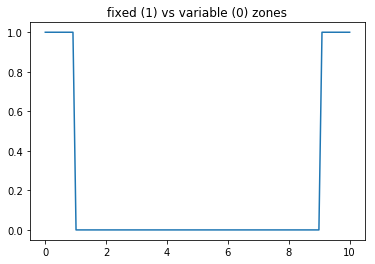

In [3]:
plt.plot(x,fixed_mask)
plt.title("fixed (1) vs variable (0) zones")

Text(0.5,0,'x (a.u.)')

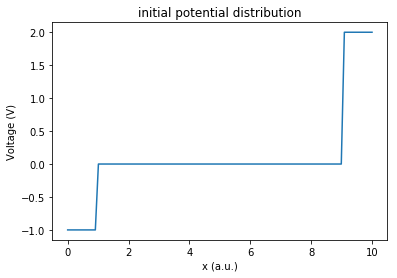

In [4]:
plt.plot(x,y)
plt.title("initial potential distribution")
plt.ylabel("Voltage (V)")
plt.xlabel("x (a.u.)")

In [5]:
def relax(y,fixed_mask):
    new_y = y * 1
    
    for i in range(len(y)):
        if fixed_mask[i]:
            continue
        new_y[i] = (y[i+1] + y[i-1])/2
    return new_y
        

saving to /workdir/jupyter/misc_mw/field_solver/poisson_1D_anim/039.png


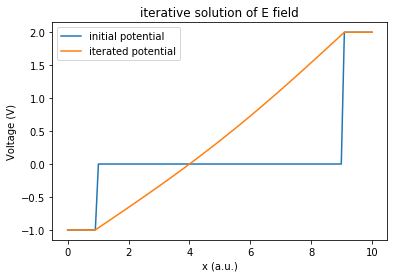

In [6]:
    
    
timesteps = 2000

clear_animation_cache()

for t in range(timesteps):
    
    y = relax(y,fixed_mask)
    if (t%50 == 0):
        clear_output(wait=True)
        plt.plot(x,y0,label="initial potential")
        plt.plot(x,y,label="iterated potential")
        plt.title("iterative solution of E field")
        plt.ylabel("Voltage (V)")
        plt.xlabel("x (a.u.)")
        plt.legend()
        save_animation_frame(plt)
        plt.show()

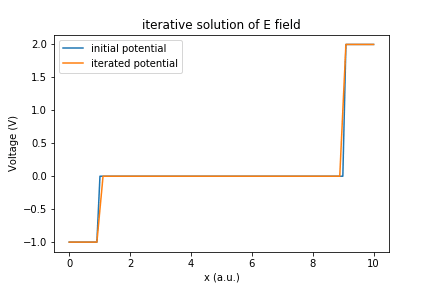

In [7]:
make_gif()